In [ ]:
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini 2.0 Flash Image Generation in Vertex AI

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb">
      <img src="https://cloud.google.com/ml-engine/images/colab-logo-32px.png" alt="Google Colaboratory logo"><br> Run in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2FGoogleCloudPlatform%2Fgenerative-ai%2Fmain%2Fgemini%2Fgetting-started%2Fiintro_gemini_2_0_image_gen_genai_sdk.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo"><br> Run in Colab Enterprise
    </a>
  </td>       
  <td style="text-align: center">
    <a href="https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb">
      <img src="https://cloud.google.com/ml-engine/images/github-logo-32px.png" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/GoogleCloudPlatform/generative-ai/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb">
      <img src="https://lh3.googleusercontent.com/UiNooY4LUgW_oTvpsNhPpQzsstV5W8F7rYgxgGBD85cWJoLmrOzhVs_ksK_vgx40SHs7jCqkTkCk=e14-rj-sc0xffffff-h130-w32" alt="Vertex AI logo"><br> Open in Vertex AI Workbench
    </a>
  </td>
</table>

<div style="clear: both;"></div>

<b>Share to:</b>

<a href="https://www.linkedin.com/sharing/share-offsite/?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/8/81/LinkedIn_icon.svg" alt="LinkedIn logo">
</a>

<a href="https://bsky.app/intent/compose?text=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/7/7a/Bluesky_Logo.svg" alt="Bluesky logo">
</a>

<a href="https://twitter.com/intent/tweet?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/53/X_logo_2023_original.svg" alt="X logo">
</a>

<a href="https://reddit.com/submit?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb" target="_blank">
  <img width="20px" src="https://redditinc.com/hubfs/Reddit%20Inc/Brand/Reddit_Logo.png" alt="Reddit logo">
</a>

<a href="https://www.facebook.com/sharer/sharer.php?u=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_2_0_image_gen_genai_sdk.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/51/Facebook_f_logo_%282019%29.svg" alt="Facebook logo">
</a>


| | |
|-|-|
|Author(s) | [Nikita Namjoshi](https://github.com/nikitamaia)|

## Overview

In this tutorial, you learn how to use Gemini 2.0 image generation features in Vertex AI using the Google Gen AI SDK.

You'll try out the following scenarios:
* text --> image
* text --> image + text (interleaved)
* text + image --> image

## Getting Started

### Install required libraries

In [1]:
%pip install --upgrade --quiet google-genai

### Authenticate your notebook environment (Colab only)

If you are running this notebook on Google Colab, run the following cell to authenticate your environment.

In [2]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

### Set Google Cloud project

To get started using Vertex AI, you must have an existing Google Cloud project and [enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

In [3]:
import os

PROJECT_ID = "your-project-id"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "us-central1")

## Use the Gemini 2.0 Flash model

In [4]:
from IPython.display import Markdown, display, Image

# import the Google Gen AI SDK
from google import genai
from google.genai.types import (
    Content,
    GenerateContentConfig,
    Part,
)

In [5]:
client = genai.Client(
    vertexai=True, project=PROJECT_ID, location=LOCATION
)

In [6]:
MODEL_ID = "gemini-2.0-flash-exp" # @param {type: "string"}

## Generate Text + Image

First, send a text prompt to Gemini 2.0 describing the image you want generated.


In the cell below, you'll call the `generate_content` method and pass in the following arguments:

* `model`: The ID of the model you want to use, in this case gemini-2.0-flash-exp
* `contents`: this is your prompt, in this case a text only user message describing the image to be generated
*`generation_config`: A config for specifying the desired `response_modalities`, in this case `TEXT` and `IMAGE`. If you do not specify `IMAGE`, you will not get image output.

In [7]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="generate an image of a grackle wearing a top hat and monocle",
    config=GenerateContentConfig(
        response_modalities=["TEXT", "IMAGE"],
    )
)

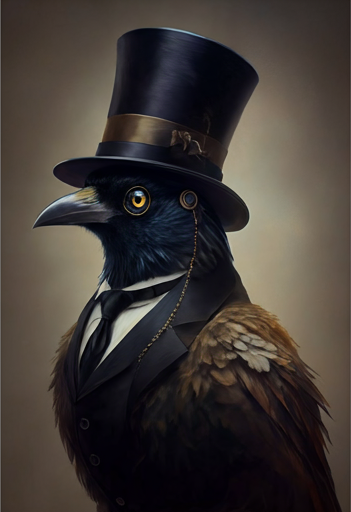

In [30]:
for part in response.candidates[0].content.parts:
  if part.inline_data:
    display(Image(data=part.inline_data.data))

## Generate Text + Image

In addition to generating images, Gemini can generate multiple images and text in an interleaved fashion.

For example, you could ask the model to generate a recipe for banana bread with image showing different stages of the cooking process. Our you could ask the model to generate a images of different wildflowers with accompanying titles and descriptions.

Let's try out the interleaved text+image functionality by prompting Gemini 2.0 to create an illustrated children's story.

Here's the prompt:

*Make a children’s storybook about a curious young fox named Mosi, who sets off on a magical adventure through a forest in search of a special star. The story unfolds over three episodes, with each episode introducing Mosi to a new friend and revealing wondrous and magical landscapes. For each episode, provide a title, a captivating narrative, and also generate a realistic image illustrating everything in the scene described in the narrative of that episode.*

You'll notice that in the prompt we ask the model to generate both text and images for each episode of the narrative. This will nudge the model to create text with images interleaved.

⚠️ Note that we are asking the model to generate a lot of content in this prompt, so it will take a bit of time for this cell to finish executing.

In [31]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Make a children’s storybook about a curious young fox named Mosi, who sets off on a magical adventure through a forest in search of a special star.  The story unfolds over three episodes, with each episode introducing Mosi to a new friend and revealing wondrous and magical landscapes.  For each episode, provide a title, a captivating narrative, and also generate a realistic image illustrating everything in the scene described in the narrative of that episode",
    config=GenerateContentConfig(
        response_modalities=["TEXT", "IMAGE"],
    )
)

The length of `content.parts` is 6 since we asked the model to produce 3 images and corresponding text for each image.

In [32]:
len(response.candidates[0].content.parts)

6

Let's visualize the response

Okay, let's create a magical storybook adventure for young Mosi!

**Episode 1: The Whispering Willow and the Firefly Lanterns**

**Narrative:**

Mosi was a young fox with fur the color of a sunset and eyes like bright amber marbles. He lived on the edge of a whispering forest, a place where the trees seemed to share secrets with the wind. One night, as the moon painted the sky silver, Mosi overheard the elder owls talking about a star that had fallen into the forest, a star that could grant wishes. Driven by curiosity, Mosi decided he had to find it. With a small knapsack filled with berries and a heart full of courage, he stepped into the woods. The trees grew tall and their leaves shimmered like emeralds. He followed a winding path until he reached a clearing. In the center stood a grand willow tree, its branches draped like a waterfall of green. Tiny fireflies blinked like living lanterns, their soft glow illuminating the clearing.  As Mosi approached, a voice, as delicate as a falling leaf, whispered, “Welcome, little fox. I am Willow, and I sense your quest.”  A firefly, larger than the others, detached itself from the willow and flew to Mosi’s nose. “Follow me, Mosi,” it chirped, “I know the way to the place where stars sometimes rest."

**Image:**



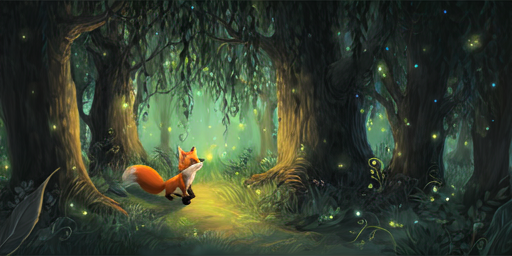



**Episode 2: The Crystal Caves and the Grumbling Badger**

**Narrative:**

Following the bright firefly, which he now called Flicker, Mosi journeyed deeper into the forest. They walked through tunnels of moss that sparkled like jewels and hopped over babbling brooks that hummed melodies to the trees. Finally, they reached the entrance of a vast cave, its mouth aglow with a soft, internal light. Inside, it was as if the stars had fallen and shattered, embedding themselves in the walls of the cave. The light reflected off countless crystals of all colors – amethyst, emerald, sapphire – creating a breathtaking spectacle. At the far end of the cave, Mosi heard a grumbling sound. It was Barnaby, a large badger with a coat the color of chocolate and a frown etched deep on his face.  “What’s all the commotion?” Barnaby growled.  Flicker introduced Mosi and explained his quest. Barnaby, despite his initial grumbling, was secretly a kind soul.  He knew the forest well.  “The star you seek is deep within the enchanted glade," he said, "but it's guarded by the Whispering Winds. I know the secret passage.”

**Image:**



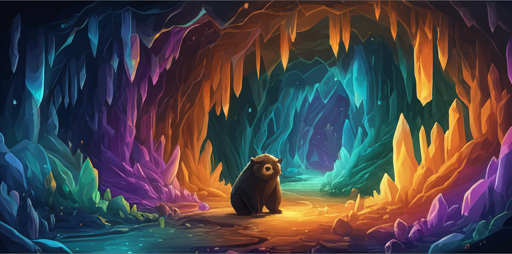



**Episode 3: The Enchanted Glade and the Wishing Star**

**Narrative:**

Barnaby led Mosi and Flicker through a secret passage behind a shimmering crystal wall. They emerged into a glade bathed in a soft, golden light.  Flowers of all shapes and colors bloomed in abundance, their petals glowing with an ethereal luminescence.  Butterflies with wings like stained glass fluttered from flower to flower. The air was filled with the sound of gentle chimes. In the center of the glade, resting on a bed of moss, was the star Mosi had been searching for. It wasn’t a fiery ball as he had imagined, but a small, silver, teardrop-shaped object that pulsed with a gentle light.  As Mosi approached, a gentle breeze swirled around them, the Whispering Winds welcoming the young fox. They told him that the star was not for wishing, but for sharing; that it held the light of kindness and wonder. Mosi, understanding at once, lifted the star. As he did, its light grew brighter, illuminating the glade with warmth. He realized that the true magic of the star was not in its power, but in the journey and the friends he had made along the way. He shared the star's light with Barnaby, Flicker, and all the creatures of the glade, filling them with happiness and a sense of wonder.

**Image:**



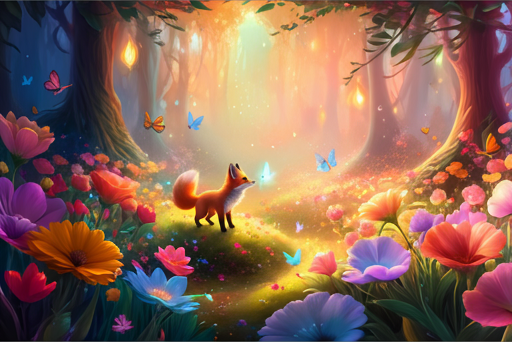

In [33]:
for part in response.candidates[0].content.parts:
  if part.text:
    display(Markdown(part.text))
  if part.inline_data:
    display(Image(data=part.inline_data.data))

## Generate a new image from a text + image prompt

You can pass text and an image to Gemini 2.0 for use cases like product captions, information about a particular image, or to make edits or modifications to an image.

Let's try out a style transfer example and ask Gemini 2.0 to create an image of this dog in the baroque style.

![small-dog-pink](https://storage.googleapis.com/cloud-samples-data/generative-ai/image/small-dog-pink.jpg)

In [36]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/small-dog-pink.jpg",
            mime_type="image/jpeg"
        ),
        "Generate a baroque style portrait painting of this dog."],
    config=GenerateContentConfig(
        response_modalities=["TEXT", "IMAGE"],
    )
)

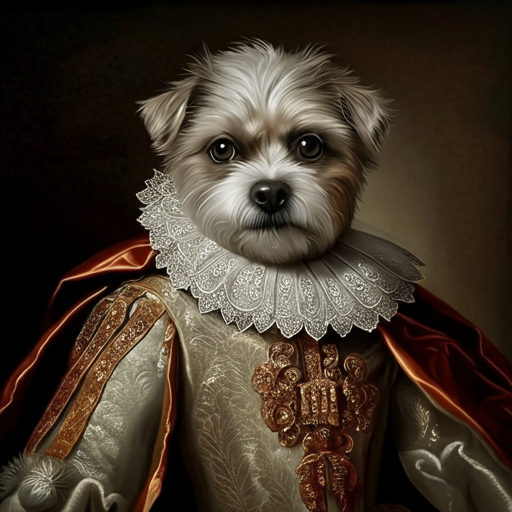

In [37]:
for part in response.candidates[0].content.parts:
  if part.inline_data:
    display(Image(data=part.inline_data.data))